# Predictive Modeling and Data Analytics for User Interaction: A Machine Learning Approach to Online Ad Engagement

# Abstract

**Purpose:**  
This study aims to develop a predictive model for online ad engagement by analyzing user cursor movements and interactions on webpages. It focuses on how factors like ad placement, timing, and user demographics affect click behavior, using machine learning to gain insights into user engagement and improve digital advertising strategies.

**Approach:**  
The project follows a structured approach that includes data preprocessing, feature engineering, exploratory analysis, model development, and evaluation. It uses the "Attentive Cursor Dataset," which combines user interaction logs, demographics, and ad-related metadata. Machine learning techniques, like Decision Tree, Random Forest, and Multi-Layer Perceptron classifiers, were applied, with hyperparameters optimized using GridSearchCV and RandomizedSearchCV.

**Solution:**  
The study finds that features like cursor speed, scroll activity, and session duration are critical in predicting ad clicks. The Random Forest model performed best, with a recall of 0.7360 and an F1 score of 0.7157. Feature importance and confusion matrix analyses provide insights into what drives user engagement and ad performance.

**Implications:**  
While the models performed well, issues like class imbalance, high feature variability limit their accuracy. These challenges show the need for better feature engineering and data handling. Future improvements, like integrating advanced models and adding richer features, could make predictions more accurate and reliable.

**Reflections:**  
This project highlights the value of cursor dynamics in predicting user behavior and improving ad engagement. With better data preparation and more focus on advanced features, future work could create even stronger models. The research shows how data-driven methods can optimize ad strategies, boost engagement, and increase revenue.

# Chapter 1: Introduction


## 1.1 Task Overview

In this project i aims to create a model that predicts if a user will click on an online ad based on their mouse cursor movement and interactions on a webpage. By analyzing cursor patterns, we aim to understand user behavior and how factors like ad placement, timing, and demographics impact the likelihood of a click on the ad.

The dataset includes user interactions, cursor movements, timestamps, and contextual details like ad type, position, and demographics. farther on We will apply machine learning to build a model that predicts the probability of a click.

The main steps include data preprocessing, feature extraction, model development, evaluation, and deployment.

## 1.2 Dataset Details

The dataset, known as the Attentive Cursor Dataset, includes the following components:

- **Groundtruth.tsv**: Contains details such as whether a user clicked on an ad, their attention score, and the session log ID.

- **Participants.tsv**: Provides demographic information, including country, age, education, income, and gender, as well as ad-related details like type, position, and category.

- **Logs Folder**: Holds CSV files that record each user's cursor movements, timestamps, positions, and events (e.g., clicks, scrolls).

The goal is to integrate these various data sources into a unified dataset and extract meaningful features to help predict ad clicks.

This dataset provides comprehensive information about user interactions, making it well-suited for building predictive models in online advertising. The detailed cursor data offers valuable insights into user engagement, which can be leveraged to predict the likelihood of ad clicks.


## 1.3 Project Steps

The project involves several key stages:

1. **Data Preprocessing**: Clean and prepare the dataset for analysis, ensuring data quality and consistency.

2. **Feature Engineering**: Extract important features from cursor data, such as speed, duration, and movement patterns, which can provide valuable insights into user behavior.

3. **Exploratory Data Analysis (EDA)**: Visualize and explore the data to identify trends, patterns, and potential relationships that may influence ad clicks.

4. **Model Development**: Develop a machine learning model to predict ad clicks based on the features extracted.

5. **Model Evaluation**: Use metrics like accuracy, precision, recall, and ROC-AUC to evaluate the model's performance and identify areas for improvement.

6. **Deployment and Future Improvements**: Deploy the model for practical use and explore opportunities for further enhancements to improve accuracy and effectiveness.

These steps provide a structured approach to understanding user behavior and optimizing online advertising strategies.



## 1.4 Libraries

### Fundamental Libraries

- **Google Auth and Google Colab Drive**: Essential tools for managing and accessing files within the Colab environment, particularly for integrating with Google Drive for data storage and retrieval.

- **Zipfile**: Enables efficient handling of ZIP archives, such as extracting datasets for analysis.

- **OS**: Provides functionalities to interact with the operating system for tasks like file manipulation, directory management, and environment interactions.

- **Pandas (pd)**: A powerful library for data manipulation and analysis, used extensively for handling structured data in DataFrame format.


### Machine Learning Libraries

- **Scikit-learn (sklearn)**: A comprehensive library for machine learning and data analysis, used for splitting datasets (`train_test_split`), evaluation metrics (e.g., `accuracy_score`), and modeling with classifiers like Decision Trees and Random Forests.

- **Sklearn.compose (ColumnTransformer)**: Simplifies applying distinct preprocessing steps to numerical and categorical features in a single pipeline.

- **Sklearn.preprocessing (StandardScaler, OneHotEncoder)**: Used for feature scaling with `StandardScaler` and encoding categorical variables with `OneHotEncoder`.

- **Sklearn.pipeline (Pipeline)**: Facilitates streamlined processing by combining preprocessing and modeling steps.

- **Sklearn.impute (SimpleImputer)**: Handles missing data by imputing values with mean, median, or other strategies.

- **Sklearn.metrics (confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score, accuracy_score)**: Offers tools for evaluating model performance, including confusion matrices, ROC-AUC, and precision-recall metrics.

- **RandomizedSearchCV and GridSearchCV**: Enables efficient hyperparameter tuning for models like Random Forest and MLPClassifier.

- **RandomForestClassifier**: A robust ensemble learning method combining decision trees to improve classification accuracy and reduce overfitting.

- **MLPClassifier**: A neural network model for multi-layer perceptron (MLP) classification tasks, designed to capture non-linear relationships in data.

### Visualization Libraries

- **Matplotlib**: Provides a foundation for creating static and interactive visualizations.

- **Sklearn.tree (plot_tree)**: For visualizing decision tree structures to interpret model decisions.

These libraries form the backbone of the project's data processing, modeling, and visualization tasks, ensuring a comprehensive and structured workflow.

# Chapter 2: Data Preprocessing

## 2.1 Bringing the Data

This script uses `google.auth`, `google.colab.drive`, `zipfile`, and `os` libraries.

1. Mount Google Drive: Connect to Google Drive to access files directly using `drive.mount()`. This is an efficient way to work in the Colab environment.

2. Define Paths: Set paths for the zip file and the extraction folder. Create the folder if it doesn't exist using `os.makedirs()`.

3. Check for Existing Extraction: Function `is_data_extracted` checks if the expected files (`groundtruth.tsv`, `participants.tsv`, and `logs`) are already in the folder to avoid unnecessary re-extraction so runing the project trow my work be faster, This function is for if the files are not already extracted, use the `zipfile` library to unzip them.

4. List and Print Contents: At the end, list and display the extracted contents to confirm successful extraction.

In [ ]:
import google.auth
from google.colab import drive
import zipfile
import os

# Mount Google Drive
drive.mount('/content/drive')

# Path to the zip file in Google Drive
zip_file_path = '/content/drive/MyDrive/cursor_adclick_data.zip'

# Path to the folder where data will be extracted
unzipped_folder = '/content/drive/MyDrive/Data'
os.makedirs(unzipped_folder, exist_ok=True)

# List of expected files or directories after extraction
expected_items = ['groundtruth.tsv', 'participants.tsv', 'logs']

# Check if the expected items are present in the unzipped folder
def is_data_extracted(folder_path, expected_items):
    return all(os.path.exists(os.path.join(folder_path, item)) for item in expected_items)

if not is_data_extracted(unzipped_folder, expected_items):
    # Extract the contents of the ZIP file to the specified folder
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(unzipped_folder)
    print('Data extracted to:', unzipped_folder)
else:
    print('Data already extracted. Skipping extraction.')

# Get the list of contents in the extracted folder
extracted_contents = os.listdir(unzipped_folder)

# Print the list of contents
print('Contents of the unzipped folder:')
for item in extracted_contents:
    print(item)

Mounted at /content/drive
Data already extracted. Skipping extraction.
Contents of the unzipped folder:
logs
participants.tsv
groundtruth.tsv


## 2.2 Data set preparation

Loading the first dataset named `groundtruth.tsv`, I then drop the `user_id` and `attention` columns, as they are not permitted for use.

In [2]:
import pandas as pd

# groundtruth.tsv path
groundtruth_file_path = os.path.join(unzipped_folder, "groundtruth.tsv")

# Load the groundtruth.tsv into a DataFrame
groundtruth_df = pd.read_csv(groundtruth_file_path, delimiter='\t')

# Drop the attention column because we are not allowed to use it
groundtruth_df.drop(columns=['attention'], inplace=True)

# Display the first few rows of the DataFrame
print(groundtruth_df.head())

                      user_id  ad_clicked          log_id
0  5npsk114ba8hfbj4jr3lt8jhf5           0  20181002033126
1  5o9js8slc8rg2a8mo5p3r93qm0           1  20181001211223
2  pi17qjfqmnhpsiahbumcsdq0r6           0  20181001170952
3  3rptg9g7l83imkbdsu2miignv7           0  20181001140754
4  049onniafv6fe4e6q42k6nq1n2           0  20181001132434


Loading the second dataset named `participants.tsv` and droping the columns i can't use in the project.

In [3]:
# participants.tsv path
participants_file_path = os.path.join(unzipped_folder, "participants.tsv")
# Load the participants.tsv into a DataFrame
participants_df = pd.read_csv(participants_file_path, delimiter='\t')
# Drop the user_id, education, age, income, and gender columns because we are not allowed to use them
participants_df.drop(columns=['user_id', 'education', 'age', 'income', 'gender'], inplace=True)
# Inspecting the first 5 rows of the DataFrame

print(participants_df.head())

  country ad_position ad_type              ad_category        serp_id  \
0     PHL    top-left      dd  Computers & Electronics        tablets   
1     VEN   top-right      dd      Shop - Luxury Goods  casio-watches   
2     VEN    top-left  native      Shop - Luxury Goods   chivas-regal   
3     VEN   top-right      dd      Shop - Luxury Goods   chivas-regal   
4     VEN    top-left  native         Autos & Vehicles   audi-r8-used   

           query          log_id  
0        tablets  20181002033126  
1  casio watches  20181001211223  
2   chivas regal  20181001170952  
3   chivas regal  20181001140754  
4   audi r8 used  20181001132434  


After bringing The datasets, i merge the two datasets (`groundtruth_df` and `participants_df`) using an inner join on the `log_id` column to retain mutual records. The merged DataFrame is then sorted by `log_id` to maintain order.

In [4]:
merged_df = pd.merge(groundtruth_df, participants_df, on=['log_id'], how='inner', indicator=True)

merged_df.sort_values(by='log_id', inplace=True)

In [5]:
# Merging table printout
print(merged_df)

                         user_id  ad_clicked          log_id country  \
1350  2fq3fhu6r693jl2sdb8fhbd190           1  20161214224444     USA   
884   mh0d0jr0oo98kriolus0ml0591           0  20161215173310     USA   
2110  hp3hqt4ifrb3q4f8vgo8e98e65           0  20161217041101     USA   
1498  9k7e1d73n5reh06p705cgp2ke7           0  20161218020519     USA   
105   j25njapljcob43qrg1cfnsg452           0  20161219223751     USA   
...                          ...         ...             ...     ...   
1445  30s7f0vmqcshiik3ikbbkrfkg5           1  20181002153456     VEN   
2503  kkve2rgsg7t74j113j0q239t75           0  20181002154613     RUS   
1556  bgcahsu0m9nb4q9fo9arklp2c2           0  20181002163229     VEN   
2639  k86ho4n6k75ib7js3vgdti4t44           0  20181002172510     VNM   
1839  7pv76sh6rs3t3gca0u07jnbcu2           0  20181002172546     ITA   

     ad_position ad_type                     ad_category  \
1350   top-right      dd         Computers & Electronics   
884     top-lef

Here i count the occurrences of the `_merge` indicator to verify the success of the merge operation. After confirming, Then i drop the `_merge` column as it is no longer needed for further analysis.

In [6]:
# Count the occurrences of the merge indicator
merged_df['_merge'].value_counts()

,count
_merge,
both,2909
left_only,0
right_only,0


In [7]:
# Drop the _merge column because it is no longer needed
merged_df.drop(columns=['_merge'], inplace=True)

I define the path to the `logs` folder and list all its contents. Since the `merged_df` is already sorted by `log_id`, I sort the log file names accordingly. I then read the first log file into a DataFrame to inspect its contents.

In [8]:
# logs folder path
logs_folder_path = os.path.join(unzipped_folder, "logs")
# List all files and directories in the logs folder
logs_folder_contents = os.listdir(logs_folder_path)
# Because the merged_df is sorted by log_id, here we will do the same for logs, as file names are the same
logs_folder_contents.sort()
# Read the first log file to see the content
log_df = pd.read_csv(f'{logs_folder_path}/{logs_folder_contents[0]}', sep=' ')

print(log_df.head())

   cursor      timestamp  xpos  ypos      event  \
0       0  1481751971767     0     0       load   
1       0  1481751977860     0     0       blur   
2       0  1481751993927     0     0      focus   
3       0  1481752002419  1342    11  mouseover   
4       0  1481752002572  1170   171  mousemove   

                                        xpath attrs  \
0                                           /    {}   
1                                           /    {}   
2                                           /    {}   
3               //*[@id='searchform']/div/div    {}   
4  //*[@id='rhs_block']/div/div/div[4]/div[1]    {}   

                                              extras  
0                                                 {}  
1                                                 {}  
2                                                 {}  
3  {"topRight":136,"topLeft":560,"bottomRight":49...  
4  {"topRight":98,"topLeft":386,"bottomRight":333...  


# Chapter 3: Prepration

## 3.1 Data Cleaning

Data Cleaning is a really importent part in the project since we going to train the model with this data is importent to do this step:

**Removing Duplicates**: Any duplicate records are removed to ensure that the dataset remains consistent.

In [9]:
# Remove Duplicate Records
merged_df.drop_duplicates(inplace=True)

## 3.2 Data visulazation

To better undrstand the target i'm going to visulazat, i first bring the headers of my marged dataframe to do the visulazation accordingly.

In [10]:
print(merged_df.columns)

Index(['user_id', 'ad_clicked', 'log_id', 'country', 'ad_position', 'ad_type',
       'ad_category', 'serp_id', 'query'],
      dtype='object')


The columns `serp_id` and `query` represent specific aspects of a search engine's data.

`serp_id`: This column represents the unique identifier for a specific search engine results page (SERP). Each SERP is generated based on a user's query and can differ depending on personalization, ranking algorithms, or the type of results displayed (e.g., ads, organic links).

`query`: This column represents the exact search term or keywords entered by the user that triggered the generation of the SERP. It directly reflects the user's intent.

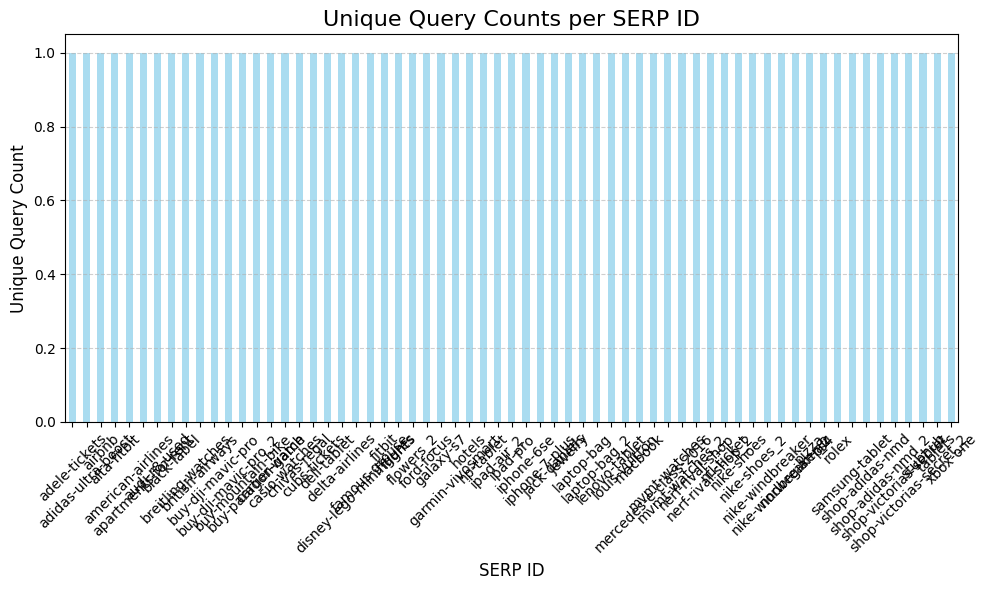

In [11]:
import matplotlib.pyplot as plt

# Count unique queries per serp_id
serp_query_counts = merged_df.groupby('serp_id')['query'].nunique()

# Visualization
plt.figure(figsize=(10, 6))
serp_query_counts.plot(kind='bar', alpha=0.7, color='skyblue')
plt.title('Unique Query Counts per SERP ID', fontsize=16)
plt.xlabel('SERP ID', fontsize=12)
plt.ylabel('Unique Query Count', fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

After analyzing the data, we can see that both columns contain a very high number of unique values. High-cardinality features like these are difficult to process effectively in machine learning models, as they can lead to issues such as overfitting or unnecessarily increasing the model's complexity. Furthermore, without significant preprocessing, these features are unlikely to provide meaningful patterns to the model. Therefore, it would be more efficient and practical to drop these two columns from the model's input.

In [12]:
merged_df.drop(columns=['serp_id','query'],inplace=True)

First checking the ad_click data to see how many 1 (click on the ad) and how many 0 (not clck on the ad) we have.

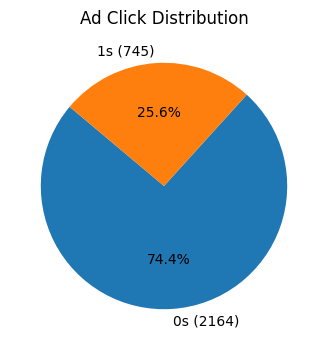

In [13]:
ad_click_counts = merged_df['ad_clicked'].value_counts()

plt.figure(figsize=(4, 4))
plt.pie(
    ad_click_counts,
    labels=[f'{label}s ({count})' for label, count in zip(ad_click_counts.index, ad_click_counts)],
    autopct='%1.1f%%',
    startangle=140
)
plt.title('Ad Click Distribution')
plt.show()

As We can see only 25.6% clicked on the ad and 74.4% have not click it

second checking the country column to see where are the most entries, i'm going to split the visulazation into 3 part:

1. Top 5 Countries by Total Entries

2. Top 5 Countries by Clicked Entries

3. Top 5 Countries by Not Clicked Entries

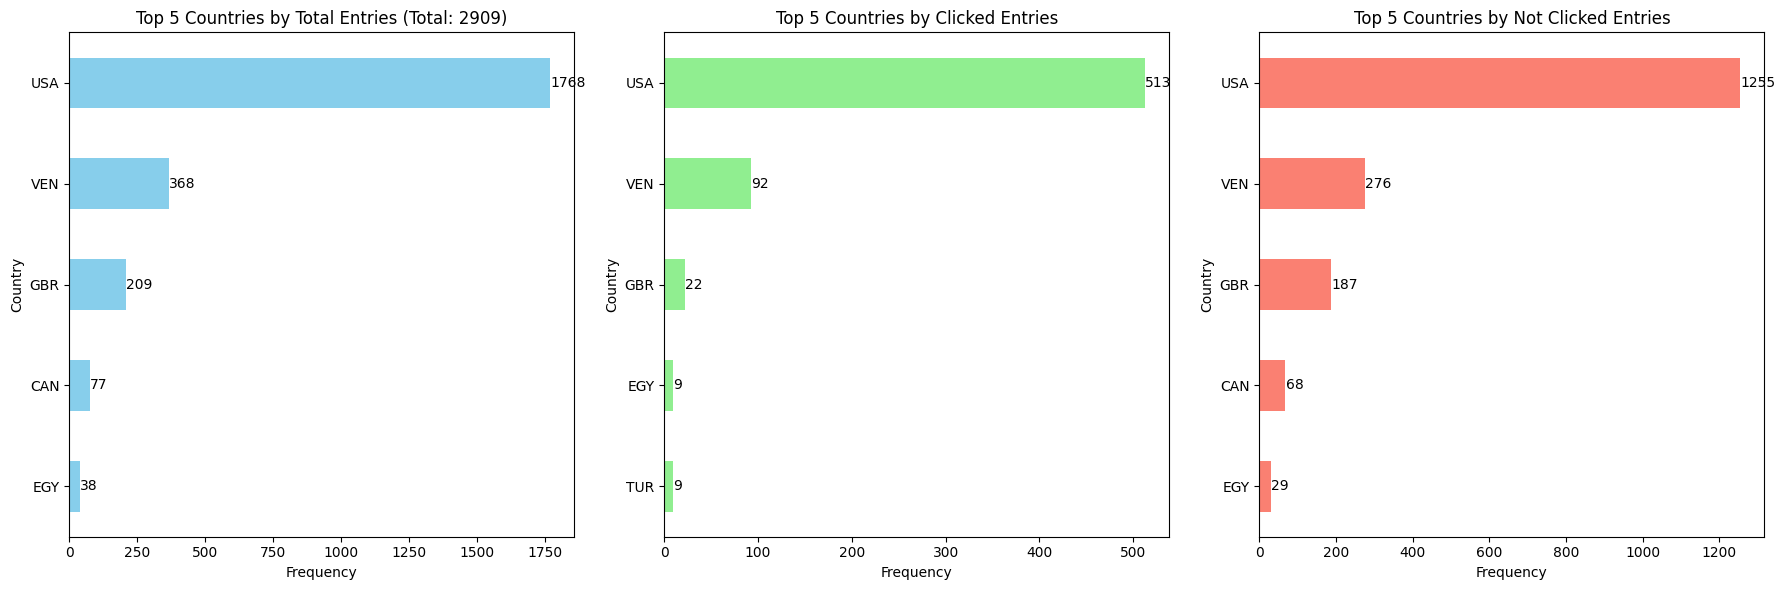

In [14]:
# Get the top 5 countries by total entries, clicked entries, and not-clicked entries
top_5_countries_total = merged_df['country'].value_counts().head(5)
top_5_countries_clicked = merged_df[merged_df['ad_clicked'] == 1]['country'].value_counts().head(5)
top_5_countries_not_clicked = merged_df[merged_df['ad_clicked'] == 0]['country'].value_counts().head(5)

# Sort the top entries for better visuals
top_5_countries_total = top_5_countries_total.sort_values(ascending=True)
top_5_countries_clicked = top_5_countries_clicked.sort_values(ascending=True)
top_5_countries_not_clicked = top_5_countries_not_clicked.sort_values(ascending=True)

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot the top 5 countries with the most total entries
top_5_countries_total.plot(
    kind='barh',
    ax=axes[0],
    color='skyblue'
)
axes[0].set_title(f'Top 5 Countries by Total Entries (Total: {merged_df.shape[0]})')
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Country')

# Annotate bars with their values
for i, value in enumerate(top_5_countries_total):
    axes[0].text(value + 0.1, i, str(value), va='center')

# Plot the top 5 countries with the most clicked entries
top_5_countries_clicked.plot(
    kind='barh',
    ax=axes[1],
    color='lightgreen'
)
axes[1].set_title('Top 5 Countries by Clicked Entries')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Country')

# Annotate bars with their values
for i, value in enumerate(top_5_countries_clicked):
    axes[1].text(value + 0.1, i, str(value), va='center')

# Plot the top 5 countries with the most not-clicked entries
top_5_countries_not_clicked.plot(
    kind='barh',
    ax=axes[2],
    color='salmon'
)
axes[2].set_title('Top 5 Countries by Not Clicked Entries')
axes[2].set_xlabel('Frequency')
axes[2].set_ylabel('Country')

# Annotate bars with their values
for i, value in enumerate(top_5_countries_not_clicked):
    axes[2].text(value + 0.1, i, str(value), va='center')

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

We can clearly see that mostly data is from Usa, i'm going to check how many countires are avaliable in the data.

In [15]:
# checking uniq values in countru column
merged_df['country'].nunique()

69

We have 69 countries in the dataset since it can't be a good indicator in the model so i drop it from the data frame

In [16]:
# Droping counrty column
merged_df.drop(columns=['country'],inplace=True)

checking the `ad_position`, `ad_type` and counting values of this two caloumns.

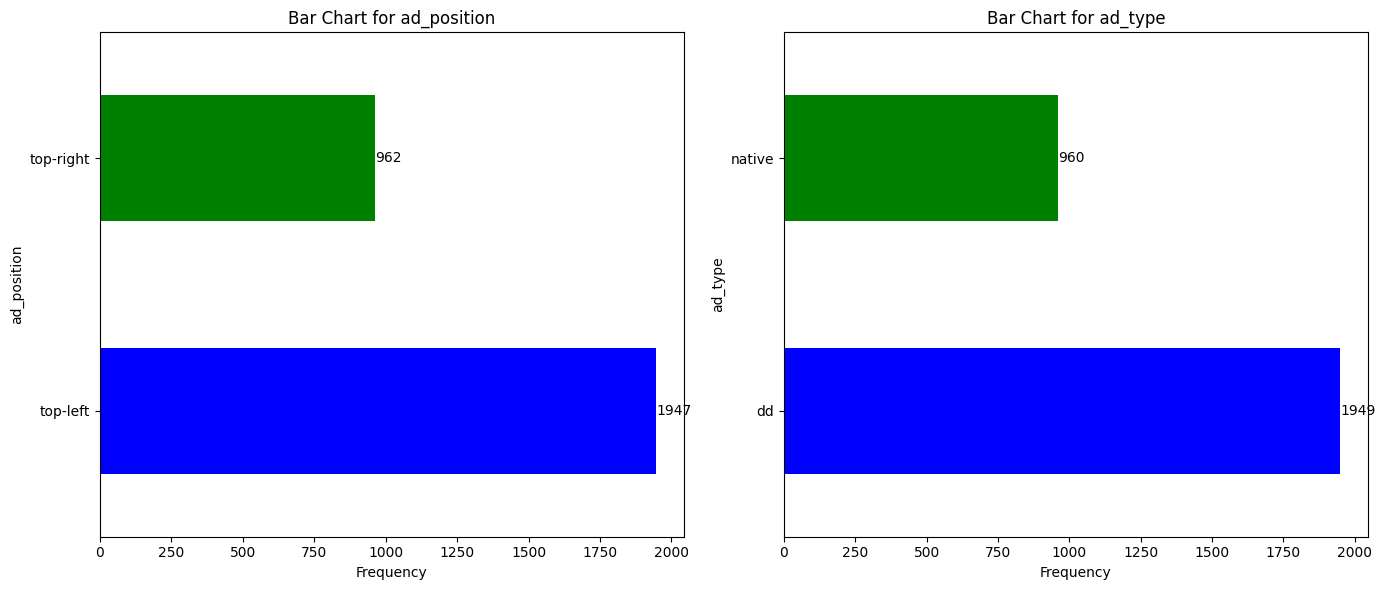

In [17]:
# Create subplots with a figure size of 14x6
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Columns to plot
columns_to_plot = ['ad_position', 'ad_type']

# Iterate over columns to create horizontal bar charts
for idx, column in enumerate(columns_to_plot):
    # Count values for each column
    value_counts = merged_df[column].value_counts()

    # Plot a horizontal bar chart for each column on the corresponding subplot
    value_counts.plot(kind='barh', ax=axes[idx], color=['blue', 'Green'])

    # Add data labels on each bar
    for i, v in enumerate(value_counts):
        axes[idx].text(v + 0.5, i, str(v), va='center')

    # Set plot title, x-axis, and y-axis labels
    axes[idx].set_title(f'Bar Chart for {column}')
    axes[idx].set_xlabel('Frequency')
    axes[idx].set_ylabel(column)

# Display the plots
plt.tight_layout()
plt.show()

it's seems like most the Top-right ads are native and only two of the rows are not, and same for top-left,but i will keep them in dataset

cheking the add categories to see how many we have and how many of the categories are got clicked on and how many are not.

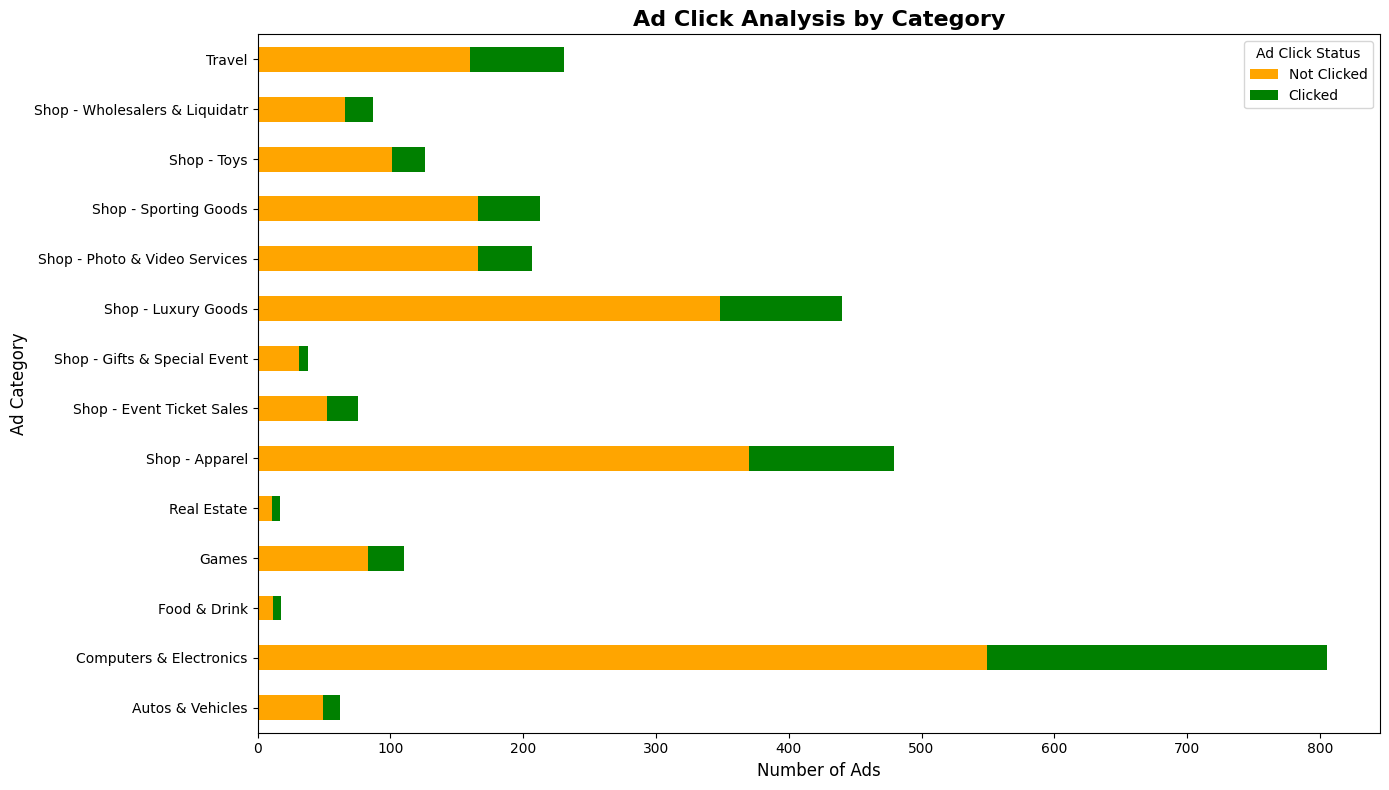

In [18]:
# Aggregate the occurrences of 'ad_clicked' within each 'ad_category'
ad_category_click_data = merged_df.pivot_table(
    index='ad_category',
    columns='ad_clicked',
    aggfunc='size',
    fill_value=0
)

# Create a horizontal stacked bar plot
ax = ad_category_click_data.plot(
    kind='barh',
    stacked=True,
    figsize=(14, 8),
    color=['orange', 'green']
)

# Customize plot labels and title
ax.set_title('Ad Click Analysis by Category', fontsize=16, weight='bold')
ax.set_xlabel('Number of Ads', fontsize=12)
ax.set_ylabel('Ad Category', fontsize=12)
ax.legend(title='Ad Click Status', labels=['Not Clicked', 'Clicked'])

# Display the plot with improved spacing
plt.tight_layout()
plt.show()

As we can see we have 14 diffrent categories but it can't be a good indicator in the model so i make a diffrent categories and make it smaller

### Creating different categories

To simplify the dataset and improve my machine learning model, I’m reducing the number of unique values by grouping similar categories. This makes the data easier to process and ensures the model focuses on meaningful patterns instead of being distracted by unnecessary details. By reorganizing the categories, I aim to enhance data consistency and clarity, helping the model perform better in feature analysis and predictions. This step is based on the observed categories and is designed to streamline the dataset for more efficient and accurate results.

In [19]:
# Define a dictionary mapping obsolete categories to new broad categories
category_mapping = {
    'Shop': [
        'Shop - Apparel',
        'Shop - Event Ticket Sales',
        'Shop - Gifts & Special Event',
        'Shop - Luxury Goods',
        'Shop - Photo & Video Services',
        'Shop - Sporting Goods',
        'Shop - Toys',
        'Shop - Wholesalers & Liquidators'
    ],
    'Technology': ['Computers & Electronics', 'Games'],
    'Hobby': ['Travel', 'Food & Drink'],
    'Finance': ['Autos & Vehicles', 'Real Estate']
}

# Create a function to map old categories to new ones
def map_category(category):
    if pd.isnull(category):
        return 'Unknown'
    for broad_category, sub_categories in category_mapping.items():
        for sub_category in sub_categories:
            if sub_category in category:
                return broad_category
    return 'Other'

# Apply the map_category function to the 'ad_category' column in merged_df
merged_df['ad_category'] = merged_df['ad_category'].apply(map_category)

## 3.3 Druations

In this task, we’re focusing only on users who spent more than 5 seconds on the website. To identify them, I’ll calculate the time each user spent on the site. This involves looping through the CSV files to find the difference between the latest (MAX) and earliest (MIN) timestamps for each user. I’ll then add this duration as a new column in the `merged_df`, as it could be a valuable feature for our models. Additionally, I'll create a dictionary to map each CSV file to its respective duration and merge them based on `log_id`, ensuring each record is correctly associated with its observation.

In [20]:
duration = {}

for csv in logs_folder_contents:
    # Construct the full file path
    file_path = os.path.join(logs_folder_path, csv)

    # Check if file is empty
    if os.path.getsize(file_path) == 0:
        print(f"Skipping empty file: {csv}")
        continue

    try:
        # Read the CSV file into a DataFrame
        df = pd.read_csv(file_path, delimiter=' ')

        # Convert timestamps to datetime objects
        df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')

        # Calculate the difference between the maximum and minimum times in seconds
        time_diff_seconds = (df['timestamp'].max() - df['timestamp'].min()).total_seconds()

        # Store the time difference in the 'duration' dictionary
        duration[int(csv[:-4])] = round(time_diff_seconds, 2)

    except pd.errors.EmptyDataError:
        print(f"Empty data in file: {csv}. Skipping.")
        continue

# Convert dictionary to DataFrame
duration_df = pd.DataFrame.from_dict(duration, orient='index', columns=['duration'])
duration_df.reset_index(inplace=True)
duration_df.rename(columns={'index': 'log_id'}, inplace=True)

# Merge dataframes
merged_df = pd.merge(merged_df, duration_df, on='log_id', how='left')

Skipping empty file: 20181001223835.csv


In [21]:
# And finally filter the data with users who spent more than 5 seconds
merged_df = merged_df[merged_df['duration'] >= 5]

# Chapter 4: Model Preparation

##  4.1 Creating Features for the Model

### Average speed - more explanation needed

One the features I want to add is cursor speed, as it can reflect the level of user engagement or hesitation while interacting with a webpage. For example, slower movements might indicate higher focus or confusion, while faster movements could suggest disinterest or confidence in navigating the page. The same process will be applied here as with duration, where I create a dictionary and map all the results based on the log ID.

In [22]:
import numpy as np
# Dictionary to store average speed for each log_id
average_speed = {}

for csv in logs_folder_contents:
    # Construct the full file path
    file_path = os.path.join(logs_folder_path, csv)

    # Check if file is empty
    if os.path.getsize(file_path) == 0:
        print(f"Skipping empty file: {csv}")
        continue

    try:
        # Read the CSV file into a DataFrame
        df = pd.read_csv(file_path, delimiter=' ')

        # Convert timestamps to datetime objects
        df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')

        # Sort the data by timestamp
        df.sort_values('timestamp', inplace=True)

        # Calculate differences in timestamps (time intervals in seconds)
        df['time_diff'] = df['timestamp'].diff().dt.total_seconds()

        # Calculate differences in cursor positions (Euclidean distance)
        df['distance'] = np.sqrt(df['xpos'].diff()**2 + df['ypos'].diff()**2)

        # Calculate speed (distance/time_diff)
        df['speed'] = df['distance'] / df['time_diff']

        # Calculate the average speed for the entire session
        avg_speed = df['speed'].mean()

        # Store the average speed in the dictionary
        average_speed[int(csv[:-4])] = round(avg_speed, 2)

    except pd.errors.EmptyDataError:
        print(f"Empty data in file: {csv}. Skipping.")
        continue
    except Exception as e:
        print(f"Error processing file {csv}: {e}")
        continue

# Convert the dictionary to a DataFrame
average_speed_df = pd.DataFrame.from_dict(average_speed, orient='index', columns=['average_speed'])
average_speed_df.reset_index(inplace=True)
average_speed_df.rename(columns={'index': 'log_id'}, inplace=True)

# Merge the average speed data with the existing dataframe
merged_df = pd.merge(merged_df, average_speed_df, on='log_id', how='left')

Skipping empty file: 20181001223835.csv


### Clicks per session

Another feature is clicks per session, which indicates user engagement. The number of clicks can reflect the level of user activity or engagement within a session. Multiple clicks could signify that the user is actively interacting with the content, searching for information, or comparing options.

In [23]:
# Dictionary to store the number of clicks for each log_id
clicks_per_session = {}

for csv in logs_folder_contents:
    # Construct the full file path
    file_path = os.path.join(logs_folder_path, csv)

    # Check if file is empty
    if os.path.getsize(file_path) == 0:
        print(f"Skipping empty file: {csv}")
        continue

    try:
        # Read the CSV file into a DataFrame
        df = pd.read_csv(file_path, delimiter=' ')

        # Count the number of "click" events in the 'event' column
        num_clicks = df['event'].str.contains('click', case=False, na=False).sum()

        # Store the number of clicks in the dictionary
        clicks_per_session[int(csv[:-4])] = num_clicks

    except pd.errors.EmptyDataError:
        print(f"Empty data in file: {csv}. Skipping.")
        continue
    except Exception as e:
        print(f"Error processing file {csv}: {e}")
        continue

# Convert the dictionary to a DataFrame
clicks_df = pd.DataFrame.from_dict(clicks_per_session, orient='index', columns=['clicks_per_session'])
clicks_df.reset_index(inplace=True)
clicks_df.rename(columns={'index': 'log_id'}, inplace=True)

# Merge the clicks data with the existing dataframe
merged_df = pd.merge(merged_df, clicks_df, on='log_id', how='left')

Skipping empty file: 20181001223835.csv


### Scroll activity

Scroll activity can also be a valuable feature in the model. High scroll activity suggests that a user is exploring and engaging deeply with the content, possibly looking for specific information or showing interest. Conversely, low scroll activity indicates limited interaction, which might correlate with disinterest or quick exits.

Since ads are most likely strategically placed in the sidebar of the page, users with high scroll counts may have encountered more ads, thereby increasing the probability of clicks.

In [24]:
# Dictionary to store the number of scroll activities for each log_id
scroll_activity_per_session = {}

for csv in logs_folder_contents:
    # Construct the full file path
    file_path = os.path.join(logs_folder_path, csv)

    # Check if file is empty
    if os.path.getsize(file_path) == 0:
        print(f"Skipping empty file: {csv}")
        continue

    try:
        # Read the CSV file into a DataFrame
        df = pd.read_csv(file_path, delimiter=' ')

        # Count the number of "scroll" events in the 'event' column
        num_scrolls = df['event'].str.contains('scroll', case=False, na=False).sum()

        # Store the number of scroll activities in the dictionary
        scroll_activity_per_session[int(csv[:-4])] = num_scrolls

    except pd.errors.EmptyDataError:
        print(f"Empty data in file: {csv}. Skipping.")
        continue
    except Exception as e:
        print(f"Error processing file {csv}: {e}")
        continue

# Convert the dictionary to a DataFrame
scroll_df = pd.DataFrame.from_dict(scroll_activity_per_session, orient='index', columns=['scroll_activity_per_session'])
scroll_df.reset_index(inplace=True)
scroll_df.rename(columns={'index': 'log_id'}, inplace=True)

# Merge the scroll activity data with the existing dataframe
merged_df = pd.merge(merged_df, scroll_df, on='log_id', how='left')

Skipping empty file: 20181001223835.csv


## 4.2 Separate the variables

In [25]:
print(merged_df)

                         user_id  ad_clicked          log_id ad_position  \
0     2fq3fhu6r693jl2sdb8fhbd190           1  20161214224444   top-right   
1     mh0d0jr0oo98kriolus0ml0591           0  20161215173310    top-left   
2     hp3hqt4ifrb3q4f8vgo8e98e65           0  20161217041101    top-left   
3     9k7e1d73n5reh06p705cgp2ke7           0  20161218020519    top-left   
4     j25njapljcob43qrg1cfnsg452           0  20161219223751    top-left   
...                          ...         ...             ...         ...   
2495  30s7f0vmqcshiik3ikbbkrfkg5           1  20181002153456    top-left   
2496  kkve2rgsg7t74j113j0q239t75           0  20181002154613   top-right   
2497  bgcahsu0m9nb4q9fo9arklp2c2           0  20181002163229    top-left   
2498  k86ho4n6k75ib7js3vgdti4t44           0  20181002172510    top-left   
2499  7pv76sh6rs3t3gca0u07jnbcu2           0  20181002172546    top-left   

     ad_type ad_category  duration  average_speed  clicks_per_session  \
0         dd  

Droping the `user_id` and `log_id` since we don't need them in the Data set anymore

In [26]:
merged_df.drop(['user_id', 'log_id'], axis=1, inplace=True)

In [27]:
# Separate the target variable (y) and feature set (X)
X = merged_df.drop('ad_clicked', axis=1)
y = merged_df[['ad_clicked']]

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Replace infinity values or too large values with NaN in the feature set only
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Select numerical and categorical columns from X
X_numeric = X.select_dtypes(include=['float64', 'int64']).columns
X_categoric = X.select_dtypes(include=['object']).columns

# Define preprocessing steps for numerical and categorical columns
numerical_transformer = Pipeline(steps=[
    ('infinity_handler', SimpleImputer(missing_values=np.nan, strategy='mean')),  # Handle NaNs from infinity values
    ('imputer', SimpleImputer(strategy='mean')),  # Impute remaining missing values
    ('scaler', StandardScaler())  # Scale numerical features
])

categorical_transformer = Pipeline(steps=[
    ('infinity_handler', SimpleImputer(strategy='most_frequent')),  # Handle NaNs from improper encoding or dropped data
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Impute missing values
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))  # One-hot encode categorical features
])

# Define column transformer for preprocessing numerical and categorical columns separately
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, X_numeric),  # Apply to numerical columns
        ('cat', categorical_transformer, X_categoric)  # Apply to categorical columns
    ]
)

# Define the model pipeline including preprocessing
model_pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Fit and transform the preprocessor on the feature set
X_processed = model_pipeline.fit_transform(X)

# Extract feature names for the processed DataFrame
numerical_feature_names = list(X_numeric)
categorical_transformer.fit(X[X_categoric])
categorical_feature_names = categorical_transformer.named_steps['onehot'].get_feature_names_out(X_categoric)

# Combine numerical and categorical feature names
all_feature_names = numerical_feature_names + list(categorical_feature_names)

# Convert the processed data back to a DataFrame
X_scaled = pd.DataFrame(X_processed, columns=all_feature_names)

# Recheck shapes for consistency
print(f"Processed data shape - X_scaled: {X_scaled.shape}")
print(f"Target variable shape - y: {y.shape}")

Processed data shape - X_scaled: (2500, 13)
Target variable shape - y: (2500, 1)


In [29]:
from sklearn.model_selection import train_test_split

# Split the dataset into training, validation, and test sets
# Split first into 70% training and 30% temporary set
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Split the temporary set into 50% validation and 50% test, which gives 15% each of original data
X_validation, X_test, y_validation, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Confirm the split shapes
print(f"Training set - X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Validation set - X_validation: {X_validation.shape}, y_validation: {y_validation.shape}")
print(f"Test set - X_test: {X_test.shape}, y_test: {y_test.shape}")

Training set - X_train: (1750, 13), y_train: (1750, 1)
Validation set - X_validation: (375, 13), y_validation: (375, 1)
Test set - X_test: (375, 13), y_test: (375, 1)


1. Training set: 1750 samples, 13 features, and 1 target value (used to train the model)
2. Validation set: 375 samples, 13 features, and 1 target value (used to tune model parameters)
3. Test set: 375 samples, 13 features, and 1 target value (used to evaluate model performance)

### Add noise

I added noise to the dataset as part of preprocessing to make the model more robust and generalizable. Since the data represents user behaviors like cursor movements and clicks, which are naturally random, adding noise mimics real-world variability and prevents the model from overfitting to specific patterns in the training set.

To do this, I used a normal distribution with a mean of 0 and a standard deviation set to 5% of the feature's original standard deviation. This ensures the noise is proportional to the variability of each feature. For example, high-variability features like cursor speed get more noise, while low-variability ones receive less. This approach maintains the underlying patterns while introducing enough randomness to challenge the model.

In [30]:
# Add noise and transform features
def preprocess_and_add_noise(df, original_columns, noise_level=0.05):
    # Copy the DataFrame
    df_noisy = df.copy()

    # Handle outliers
    df_noisy['duration'] = df_noisy['duration'].clip(upper=10000)
    df_noisy['average_speed'] = df_noisy['average_speed'].clip(upper=50000)
    df_noisy['scroll_activity_per_session'] = df_noisy['scroll_activity_per_session'].clip(upper=50)
    df_noisy['clicks_per_session'] = df_noisy['clicks_per_session'].clip(upper=100)

    # Add log-transformed features
    df_noisy['log_duration'] = np.log1p(df_noisy['duration'])
    df_noisy['log_average_speed'] = np.log1p(df_noisy['average_speed'])
    df_noisy['log_scroll_activity'] = np.log1p(df_noisy['scroll_activity_per_session'])
    df_noisy['log_clicks_per_session'] = np.log1p(df_noisy['clicks_per_session'])

    # Add noise to numeric features
    numeric_cols = df_noisy.select_dtypes(include=['float64', 'int64']).columns
    for col in numeric_cols:
        noise = np.random.normal(0, noise_level * df_noisy[col].std(), size=df_noisy[col].shape)
        df_noisy[col] += noise

    # Ensure the features align with the original training columns
    return df_noisy[original_columns]

In [31]:
# Original training feature columns
original_columns = X_train.columns.tolist()

# Preprocess and add noise to create a noisy dataset
X_train_noisy = preprocess_and_add_noise(X_train, original_columns, noise_level=0.05)

# Add a label column to distinguish between original and noisy data
X_train['data_type'] = 'original'
X_train_noisy['data_type'] = 'noisy'

# Concatenate original data with noisy data
X_train_combined = pd.concat([X_train, X_train_noisy], axis=0).reset_index(drop=True)

# Duplicate y_train for noisy data
y_train_noisy = y_train.copy()
y_train_combined = pd.concat([y_train, y_train_noisy], axis=0).reset_index(drop=True)

# Ensure the combined dataset contains both original and noisy data
print(X_train_combined['data_type'].value_counts())

# Print the final shapes of X_train and y_train
print(f"Training set - X_train: {X_train_combined.shape}, y_train: {y_train_combined.shape}")

data_type
original    1750
noisy       1750
Name: count, dtype: int64
Training set - X_train: (3500, 14), y_train: (3500, 1)


/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [32]:
X_train_combined = X_train_combined.drop(columns=['data_type'])

## 4.3 Confusion Matrix

The `conf_matrx` function is designed to generate and display a confusion matrix for evaluating a model's performance. It takes true labels, predicted labels, and the model type as inputs. Using `sklearn.metrics.confusion_matrix`, it calculates the confusion matrix and formats it into a more readable `pandas.DataFrame`. This DataFrame is labeled with class names (`red`, `green`, `yellow`) based on the size of the matrix. The function then prints the labeled confusion matrix with the specified model name for context. This tool provides a clear summary of the model’s classification accuracy, making it easier to assess performance visually.

In [33]:
from sklearn.metrics import confusion_matrix

# Confusion Matrix Function
def conf_matrx(true_labels, predicted_labels, model_type):

    class_labels = ["red", "green", "yellow"]

    # Create the confusion matrix
    cm = confusion_matrix(true_labels, predicted_labels)

    # Convert it into a DataFrame for better readability
    cm_df = pd.DataFrame(cm,
                         index=class_labels[:cm.shape[0]],
                         columns=class_labels[:cm.shape[1]])

    # Print the confusion matrix
    print(f"Confusion Matrix For {model_type}:")
    print(cm_df)

## 4.4 ROC AUC Curve Plotting

The `roc_auc` function plots ROC AUC curves for a multi-class classifier, helping evaluate its performance. It requires a trained classifier (`clf`), model name, features (`X`), and true labels (`y`). The function calculates the false positive rate (FPR), true positive rate (TPR), and area under the curve (AUC) for each class using `sklearn.metrics.roc_curve` and `auc`. It visualizes these metrics on a plot, showing each class’s ROC curve along with a reference line for random classification. This plot highlights the classifier's ability to distinguish between classes, offering insights into its predictive power and robustness.

In [34]:
from sklearn.metrics import roc_curve, auc

# ROC AUC Curve Plotting Function
def roc_auc(clf, modelname, X, y):

    # Get predicted probabilities
    vals = clf.predict_proba(X)

    # Number of classes
    n_classes = vals.shape[1]

    # Initialize dictionaries for False Positive Rates, True Positive Rates, and AUC values
    fpr = dict()
    tpr = dict()
    roc_auc_values = dict()

    # Calculate FPR, TPR, and AUC for each class
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y, vals[:, i], pos_label=i)
        roc_auc_values[i] = auc(fpr[i], tpr[i])

    # Plotting the ROC AUC curves
    plt.figure(figsize=(8, 6))
    for i in range(n_classes):
        plt.plot(
            fpr[i],
            tpr[i],
            lw=2,
            label=f"Class {i} (AUC = {roc_auc_values[i]:.2f})"
        )

    # Plot the reference line for a random classifier
    plt.plot([0, 1], [0, 1], color="navy", linestyle="--", label="Random classifier")

    # Set plot labels and title
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{modelname}: ROC Curves")
    plt.legend(loc="lower right")

    # Show the plot
    plt.show()

# Chapter 5: Model Creation

## 5.1 Scores dictionary

First we open a dictionary to store the scores so we can easily compare the result

In [35]:
# Initialize the scores dictionary
scores_dict = {}

## 5.2 Decision Tree Classifier

The first model I selected for the task is the **Decision Tree Classifier**. Decision trees are straightforward yet powerful models that are particularly effective for datasets with mixed types of features (categorical and numerical) and complex relationships between variables. Given the nature of our data, which includes noisy cursor behavior and ad interaction features, a Decision Tree is a suitable choice for uncovering patterns and providing clear insights into the decision-making process.



### Why Choose Decision Tree?

1. **Interpretability**: Decision Trees are highly interpretable compared to other models. They produce a visual representation (tree structure) that allows us to see how decisions are made, which is essential for understanding and validating the model’s predictions.
2. **Handling Noisy Data**: With noisy user behavior data, the Decision Tree’s structure helps isolate meaningful splits based on the most important features, improving the ability to make accurate predictions.
3. **Handling Missing Data**: The tree’s splitting mechanism can still function effectively even when some data is missing, making it more flexible for real-world datasets.
4. **Balance of Simplicity and Effectiveness**: Decision Trees balance simplicity and predictive power, making them an excellent first choice for model exploration and baseline comparisons.

### Optimization and Parameter Tuning

To optimize the Decision Tree, I applied **GridSearchCV** to systematically test various combinations of hyperparameters. The parameters tuned included:
- **Maximum Depth (`max_depth`)**: Limits the depth of the tree to avoid overfitting.
- **Minimum Samples per Leaf (`min_samples_leaf`)**: Ensures that leaf nodes have a minimum number of data points, improving generalization.
- **Minimum Samples for Splitting (`min_samples_split`)**: Controls the minimum number of samples required to split a node.
- **Cost Complexity Pruning (`ccp_alpha`)**: Prunes the tree to reduce overfitting by balancing complexity and accuracy.

The best configuration was chosen based on the weighted F1 score, prioritizing a balance between precision and recall across the classes.

### Advantages of Decision Tree for This Dataset

- **Feature Transparency**: The tree structure highlights which features (e.g., cursor speed, ad type, or session duration) are most influential in predicting user clicks.
- **Class Weighting**: By incorporating class weights, the Decision Tree adjusts for the imbalance between clicked and non-clicked ads, ensuring better performance on minority classes.
- **Visualization**: The ability to visualize the decision-making process provides valuable insights into user behavior patterns, such as identifying the conditions under which users are more likely to click on ads.

### Key Features of the Implementation

- The **GridSearchCV** ensured that the model was fine-tuned for the best performance on the validation data.
- The model’s predictions were evaluated using metrics such as precision, recall, F1 score, and accuracy to comprehensively assess its performance.
- A detailed visualization of the tree structure provided interpretable insights into the model's logic, making it a valuable tool for both predictive accuracy and understanding.

The Decision Tree serves as an excellent baseline model, offering interpretable results and foundational insights into the data while providing a clear starting point for further refinement or comparison with more advanced models.

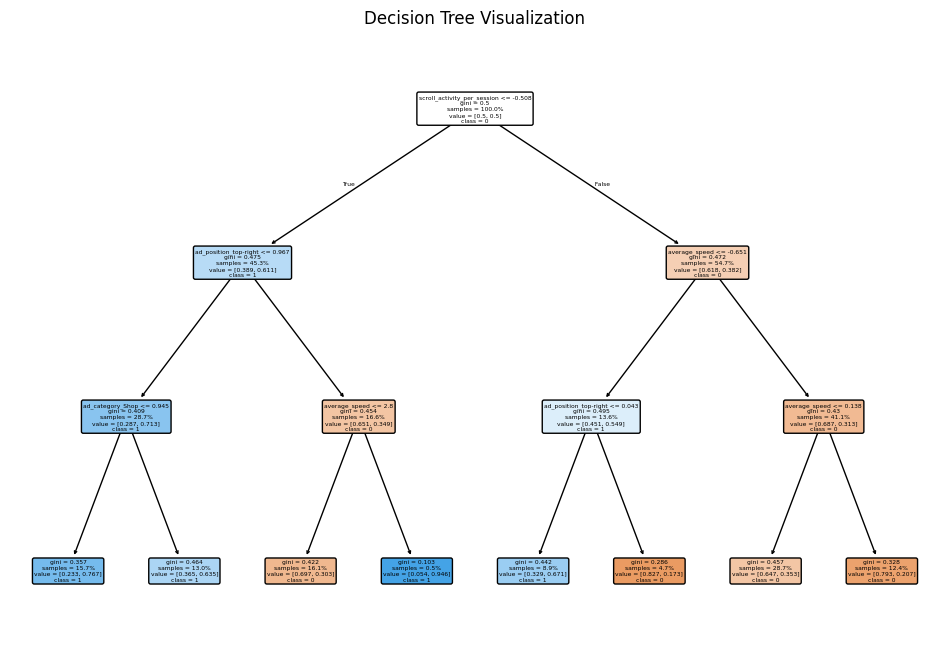

In [36]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_leaf': [2, 4, 6],
    'min_samples_split': [5, 10, 15],
    'ccp_alpha': [0.0, 0.01, 0.05]
}

# Initialize the decision tree classifier with class balancing
decision_tree = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)

# Using GridSearchCV for Decision Tree hyperparameter tuning
grid_search = GridSearchCV(
    estimator=decision_tree,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

# Fit GridSearchCV on the training data
grid_search.fit(X_train_combined, y_train_combined)
best_dec_tree = grid_search.best_estimator_

# Predict on the validation data
dec_tree_preds = best_dec_tree.predict(X_validation)

# Calculate evaluation metrics for Decision Tree
dec_tree_precision = precision_score(y_validation, dec_tree_preds, average='weighted')
dec_tree_recall = recall_score(y_validation, dec_tree_preds, average='weighted')
dec_tree_f1 = f1_score(y_validation, dec_tree_preds, average='weighted')
dec_tree_accuracy = accuracy_score(y_validation, dec_tree_preds)

# Store Decision Tree results in the dictionary
scores_dict["Decision Tree"] = {
    "Precision": f"{dec_tree_precision:.4f}",
    "Recall": f"{dec_tree_recall:.4f}",
    "F1 Score": f"{dec_tree_f1:.4f}",
    "Accuracy": f"{dec_tree_accuracy:.4f}"
}

# Plot the Decision Tree
plt.figure(figsize=(12, 8))
plot_tree(
    best_dec_tree,
    feature_names=original_columns,
    class_names=[str(cls) for cls in best_dec_tree.classes_],
    filled=True, rounded=True, proportion=True
)
plt.title("Decision Tree Visualization")
plt.show()

### Results of the Decision Tree Classifier

#### Overall Performance Metrics

In [37]:
# Print metrics for the Decision Tree
print("\nDecision Tree Metrics:")
for metric, score in scores_dict["Decision Tree"].items():
    print(f"{metric}: {score}")


Decision Tree Metrics:
Precision: 0.7562
Recall: 0.6640
F1 Score: 0.6872
Accuracy: 0.6640


- **Precision: 0.7562**  
  Precision measures how many of the predicted positive cases are correct. A precision of 0.7562 indicates that approximately 75.62% of the times the model predicts a positive outcome (e.g., a user will click on an ad), it is accurate. This demonstrates a strong ability to avoid false positives.  

- **Recall: 0.6640**  
  Recall measures how many of the actual positive cases are identified by the model. With a recall of 0.6640, the model correctly identifies about 66.40% of true positive cases. This indicates that some cases are missed (false negatives), meaning the model occasionally fails to detect users who would actually click.

- **F1 Score: 0.6872**  
  The F1 score provides a balance between precision and recall. With a score of 0.6872, the model achieves a moderate balance between minimizing false positives and capturing true positives.

- **Accuracy: 0.6640**  
  Accuracy measures the proportion of all predictions, both positive and negative, that are correct. At 66.40%, the model classifies approximately two-thirds of the total cases accurately.

#### Confusion Matrix Analysis

In [38]:
conf_matrx(y_validation, dec_tree_preds, "Decision Tree Classifier")

Confusion Matrix For Decision Tree Classifier:
       red  green
red    185     99
green   27     64


The confusion matrix provides a detailed breakdown of the model's predictions and how they compare to the actual labels:

- **True Positives (green classified as green): 64**  
  The model correctly predicted 60 cases where a user would click on an ad.

- **False Positives (red classified as green): 99**  
  These are cases where the model incorrectly predicted a user would click on an ad when they did not.

- **True Negatives (red classified as red): 185**  
  The model correctly predicted 185 cases where a user did not click on an ad.

- **False Negatives (green classified as red): 27**  
  These are instances where the model failed to identify users who clicked on an ad, predicting they would not.

The model shows a better capability to predict negative outcomes accurately (185 true negatives) compared to positive outcomes (64 true positives). This highlights a potential bias toward the majority class.

#### ROC Curve Analysis

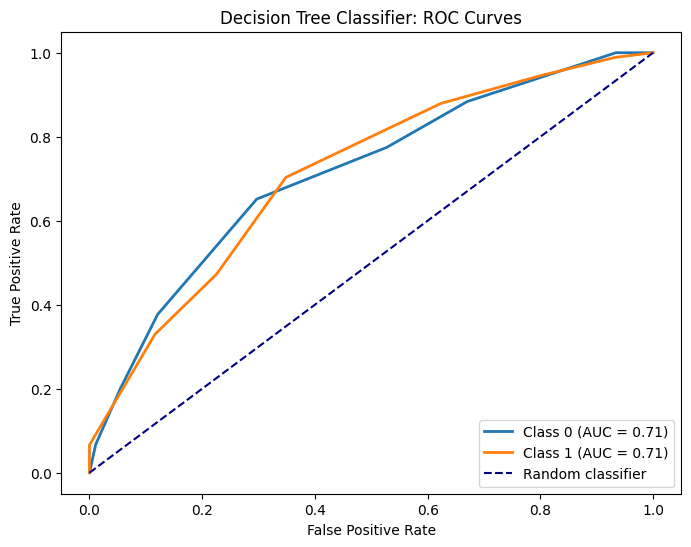

In [39]:
roc_auc(best_dec_tree, "Decision Tree Classifier", X_validation, y_validation)

The ROC curve illustrates the trade-off between the true positive rate (sensitivity) and the false positive rate at various thresholds:

- **AUC (Area Under Curve): 0.71**  
  An AUC of 0.71 indicates the model's ability to distinguish between users who clicked and did not click is better than random guessing (which would have an AUC of 0.5), but it is not exceptionally strong.

- **Observation**:  
  The upward trajectory of the ROC curve reflects the model's ability to capture some patterns in the data. However, the relatively low AUC suggests there is significant room for improvement.

#### Interpretation in Context

- **Strengths**:
  - The model performs reasonably well, considering the dataset’s complexity and the imbalance between clicked and non-clicked ads.
  - High precision is particularly useful for minimizing false positives, which is crucial in applications like targeted advertising to avoid unnecessary ad spend on uninterested users.

- **Weaknesses**:
  - The moderate recall and F1 score indicate the model misses some cases where users would click on ads. This is a concern because failing to identify potential clicks could mean lost opportunities for targeting interested users.



### Conclusion for decision tree classifier


  The Decision Tree Classifier provides an interpretable baseline model with reasonable accuracy and precision. However, the results suggest that while it captures some patterns, improvements (e.g., feature engineering, handling class imbalance) are needed to boost recall and overall predictive power. This analysis highlights the model's potential and areas for refinement in future iterations.

## 5.3 Random Forest Classifier

The second model I chose to use is the **Random Forest Classifier**, a robust and versatile ensemble method that works by combining multiple decision trees to improve prediction accuracy and reduce overfitting. This makes it a natural progression from the Decision Tree model, offering greater stability and better generalization to unseen data.

### Why Choose Random Forest?

Random Forest is particularly suited for this dataset for several reasons:
1. **Handling Missing Values and Noise**: The dataset has complexities such as noisy user interaction data (e.g., cursor patterns). Random Forest is resilient to such issues because it combines the predictions of multiple decision trees, making it less sensitive to noise in the data.
2. **Feature Importance**: It provides a clear measure of feature importance, helping us understand which features (e.g., cursor speed, session duration, ad type) are most critical for predicting user clicks.
3. **Class Imbalance Handling**: Random Forest supports balancing techniques, such as class weighting, which ensures that the minority class (e.g., clicked ads) gets appropriate attention during training.
4. **Scalability**: With its parallelized structure, Random Forest can handle large datasets and multiple features efficiently, which is important given the richness of the data (including cursor movement, user demographics, and ad details).

### How the Model Was Optimized

To ensure the model performs optimally, I used **Randomized Search CV** for hyperparameter tuning. This approach efficiently explores a broad range of hyperparameter combinations, including:
- **Number of Trees (`n_estimators`)**: Determines how many decision trees are included in the forest.
- **Maximum Depth (`max_depth`)**: Controls how deep the trees can grow to prevent overfitting.
- **Minimum Samples for Splitting and Leaf Nodes (`min_samples_split`, `min_samples_leaf`)**: Ensures that splits and leaves have a minimum number of data points, improving generalization.
- **Bootstrap Sampling (`bootstrap`)**: Determines whether sampling with replacement is used to build the trees, which can add randomness and robustness.
- **Class Weight (`class_weight`)**: Adjusts the importance of each class to handle imbalance in the target variable.

The best hyperparameter combination was selected based on the weighted F1 score, which ensures that the model balances precision and recall effectively across all classes.

### Advantages Over Single Decision Trees

- **Reduced Overfitting**: By averaging predictions across multiple trees, Random Forest minimizes overfitting, a common issue in standalone decision trees.
- **Improved Accuracy**: It tends to be more accurate, as it integrates the "wisdom of crowds" concept by aggregating predictions.
- **Robustness**: Random Forest is less sensitive to variations in the data and performs well on noisy datasets.

This model is expected to provide a significant improvement in recall and overall predictive power compared to the single Decision Tree model. The final evaluation will include precision, recall, F1 score, accuracy, a confusion matrix, and the ROC curve to understand its performance fully.

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter grid for hyperparameter tuning
rf_param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

# Initialize the Random Forest Classifier
random_forest = RandomForestClassifier(
    random_state=42
)

# Using RandomizedSearchCV for Random Forest hyperparameter tuning
rf_random_search = RandomizedSearchCV(
    estimator=random_forest,
    param_distributions=rf_param_grid,
    n_iter=50,
    cv=3,
    scoring='f1_weighted',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit RandomizedSearchCV on the training data
rf_random_search.fit(X_train_combined, y_train_combined)
best_rf = rf_random_search.best_estimator_

# Predict on the validation data
rf_preds = best_rf.predict(X_validation)

# Calculate evaluation metrics for Random Forest
rf_precision = precision_score(y_validation, rf_preds, average='weighted')
rf_recall = recall_score(y_validation, rf_preds, average='weighted')
rf_f1 = f1_score(y_validation, rf_preds, average='weighted')
rf_accuracy = accuracy_score(y_validation, rf_preds)

# Store Random Forest results in the dictionary
scores_dict["Random Forest"] = {
    "Precision": f"{rf_precision:.4f}",
    "Recall": f"{rf_recall:.4f}",
    "F1 Score": f"{rf_f1:.4f}",
    "Accuracy": f"{rf_accuracy:.4f}"
}

Fitting 3 folds for each of 50 candidates, totalling 150 fits


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


### Results of the Random Forest Classifier

#### Overall Performance Metrics

In [41]:
# Print metrics for Random Forest
print("\nRandom Forest Metrics:")
for metric, score in scores_dict["Random Forest"].items():
    print(f"{metric}: {score}")


Random Forest Metrics:
Precision: 0.7575
Recall: 0.7173
F1 Score: 0.7311
Accuracy: 0.7173


- **Precision: 0.7575**  
  Precision measures how many of the predicted positive cases are correct. With a precision of 0.7575, about 75.75% of the times the model predicts a positive outcome (e.g., a user will click on an ad), it is accurate. This reflects a reasonable ability to avoid false positives.  

- **Recall: 0.7173**  
  Recall measures how many of the actual positive cases are identified by the model. A recall of 0.7173 means the model correctly identifies 71.73% of true positive cases. This indicates the model captures a majority of the positive cases, though some are still missed (false negatives).

- **F1 Score: 0.7311**  
  The F1 score balances precision and recall. With a score of 0.7311, the model achieves a good balance between avoiding false positives and capturing true positives, slightly favoring recall.

- **Accuracy: 0.7173**  
  Accuracy measures the proportion of all predictions (both positive and negative) that are correct. With an accuracy of 71.73%, the model correctly classifies over two-thirds of the total cases, indicating a solid overall performance.

#### Confusion Matrix Analysis

In [42]:
conf_matrx(y_validation, rf_preds, "Random Forest Classifier")

Confusion Matrix For Random Forest Classifier:
       red  green
red    213     71
green   35     56


The confusion matrix provides a detailed breakdown of the model's predictions compared to the actual labels:

- **True Positives (green classified as green): 56**  
  The model correctly predicted 56 cases where a user clicked on an ad.

- **False Positives (red classified as green): 71**  
  These are cases where the model incorrectly predicted a user would click on an ad when they did not.

- **True Negatives (red classified as red): 213**  
  The model correctly identified 213 cases where a user did not click on an ad.

- **False Negatives (green classified as red): 35**  
  These are instances where the model failed to identify users who clicked on an ad, predicting they would not.

The Random Forest classifier shows a strong ability to correctly predict negatives (213 true negatives), but the relatively high count of false negatives (35) highlights room for improvement in identifying positive cases.

#### ROC Curve Analysis

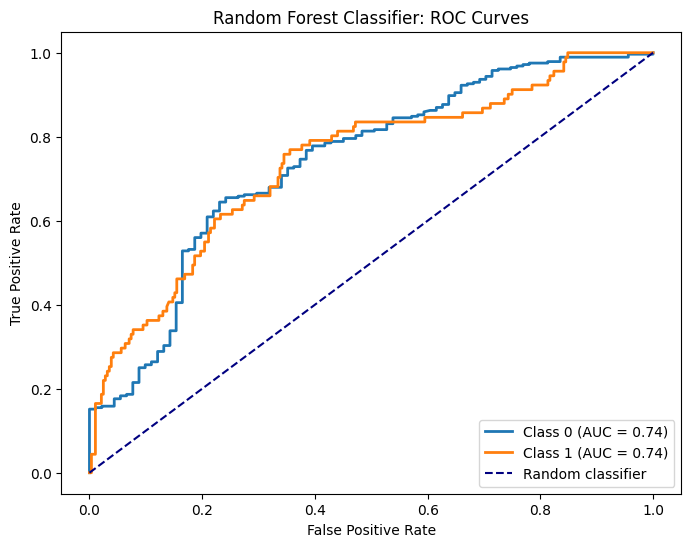

In [43]:
roc_auc(best_rf, "Random Forest Classifier", X_validation, y_validation)

The ROC (Receiver Operating Characteristic) curve illustrates the model's trade-off between the true positive rate (sensitivity) and the false positive rate:

- **AUC (Area Under Curve): 0.74**  
  An AUC of 0.74 indicates that the model's ability to distinguish between users who clicked and did not click is significantly better than random guessing (AUC of 0.5). This reflects a reasonably strong predictive capability.

- **Observation**:  
  The upward trajectory of the ROC curve and the AUC score suggest the model is capable of capturing patterns in the data, though there is still potential for further optimization.

#### Interpretation in Context

- **Strengths**:
  - The Random Forest classifier outperforms the Decision Tree in recall and accuracy, making it better at identifying true positives while maintaining strong general performance.
  - Its higher AUC score and improved overall metrics indicate it captures more signal from the data, leveraging its ensemble nature to reduce overfitting.
  - High precision ensures that a majority of the positive predictions (e.g., clicks) are accurate, reducing false alarms.

- **Weaknesses**:
  - The model still has a notable number of false negatives (65), meaning it misses a considerable portion of users who actually clicked on ads.
  - The false positives (34) are also an area for improvement, as incorrectly predicting clicks could lead to inefficiencies in targeted advertising.


### Conclusion for random forest classifier

The Random Forest classifier demonstrates a solid improvement over the Decision Tree, particularly in recall and accuracy. This makes it a better option for scenarios where identifying true positives is critical, such as optimizing ad placements for maximum engagement. While the results are promising, further enhancements, such as fine-tuning hyperparameters or incorporating additional features, could improve its ability to minimize false negatives and further increase predictive performance.

## 5.4 MLP

The third model I selected is the **Multi-Layer Perceptron (MLP) Classifier**, which is a type of artificial neural network designed for supervised learning tasks. MLPs are particularly effective for datasets where relationships between variables are complex and may not be easily captured by simpler models like Decision Trees or Random Forests. Given the intricate nature of our dataset—featuring features like cursor movement, session behavior, and categorical ad details—MLPs offer the capacity to model these nonlinear interactions effectively.

### Why Choose MLP Classifier?

1. **Modeling Complex Patterns**: MLPs are well-suited for detecting and modeling nonlinear relationships in data, which can be challenging for other algorithms. This is particularly useful in datasets with diverse features.
2. **Scalability**: Neural networks can scale with large datasets, making MLP an excellent choice for richer datasets like ours.
3. **Feature Independence**: MLPs do not assume feature independence, allowing them to make better predictions in datasets where variables interact heavily.
4. **Flexibility**: MLPs support a variety of hyperparameters (e.g., hidden layers, activation functions) that can be tuned to fit specific tasks, ensuring adaptability to the unique characteristics of the dataset.

### Optimization and Parameter Tuning

To optimize the MLP classifier’s performance, I utilized two approaches:
1. **Grid Search**: This systematically explores a predefined set of hyperparameters to find the best-performing model.
2. **Randomized Search**: This approach samples random combinations of hyperparameters, allowing a broader search of the hyperparameter space within fewer iterations.

#### Hyperparameters Tuned

- **Hidden Layers**: The number and size of hidden layers were varied (e.g., `(50,)`, `(100,)`, and `(100, 50)`), enabling the model to adapt its complexity.
- **Activation Functions**: `relu` and `tanh` were used to explore different types of nonlinearity.
- **Learning Rate**: Both constant and adaptive learning rates were tested to balance convergence speed and stability.
- **Alpha**: The regularization term was adjusted to control overfitting.
- **Max Iterations**: Models were allowed up to 1000 iterations to ensure convergence.

Both search methods aimed to maximize the weighted F1 score, which balances precision and recall across the classes.

### Advantages of MLP for This Dataset

- **Nonlinear Modeling**: The MLP’s ability to learn nonlinear relationships makes it well-suited for capturing intricate patterns in the data, such as those underlying user behavior and interactions.
- **Robustness**: Through regularization (`alpha`) and grid/randomized searches, the MLP can generalize well without overfitting.
- **Feature Interaction**: MLP can model dependencies between features (e.g., cursor movement and session duration), which is crucial for predicting ad clicks effectively.

### Key Features of the Implementation

1. **Grid Search vs. Randomized Search**: Both methods explored hyperparameter combinations, with Randomized Search offering a more efficient exploration of the parameter space.
2. **Metrics**: Precision, recall, F1 score, and accuracy were used to evaluate model performance comprehensively.
3. **Evaluation**: Confusion matrices and ROC curves were generated to gain insights into the classification performance.

### What to Expect from MLP Classifier?

Compared to the Decision Tree and Random Forest models, the MLP classifier is expected to:
- Perform better at modeling complex interactions between features.
- Provide improved recall, identifying more true positives (e.g., correctly predicting users who click ads).
- Potentially exhibit a slight increase in precision or F1 score, depending on the level of noise and feature importance in the dataset.

While MLPs require careful hyperparameter tuning and can be computationally intensive, they offer significant flexibility and predictive power for datasets with rich, nonlinear patterns, making them a strong candidate for this task.

In [44]:
from sklearn.neural_network import MLPClassifier

# Grid Search for MLP Classifier
mlp_param_grid = {
    'hidden_layer_sizes': [(50,), (100,)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': [0.001, 0.01],
    'learning_rate': ['constant', 'adaptive'],
    'max_iter': [500, 1000]
}

grid_search_mlp = GridSearchCV(
    estimator=MLPClassifier(random_state=42),
    param_grid=mlp_param_grid,
    cv=2,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2
)

# Fit the Grid Search model
grid_search_mlp.fit(X_train_combined, y_train_combined)

# Best model from Grid Search
best_mlp_grid = grid_search_mlp.best_estimator_

# Predict and evaluate on validation set
grid_mlp_preds = best_mlp_grid.predict(X_validation)

# Calculate evaluation metrics for Grid Search model
grid_mlp_precision = precision_score(y_validation, grid_mlp_preds, average='weighted')
grid_mlp_recall = recall_score(y_validation, grid_mlp_preds, average='weighted')
grid_mlp_f1 = f1_score(y_validation, grid_mlp_preds, average='weighted')
grid_mlp_accuracy = accuracy_score(y_validation, grid_mlp_preds)

# Store Grid Search results in the dictionary
scores_dict["MLP Classifier (Grid Search)"] = {
    "Precision": f"{grid_mlp_precision:.4f}",
    "Recall": f"{grid_mlp_recall:.4f}",
    "F1 Score": f"{grid_mlp_f1:.4f}",
    "Accuracy": f"{grid_mlp_accuracy:.4f}"
}



# Randomized Search for MLP Classifier
mlp_param_dist = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': np.logspace(-3, -1, 3),
    'learning_rate': ['constant', 'adaptive'],
    'max_iter': [500]
}

random_search_mlp = RandomizedSearchCV(
    estimator=MLPClassifier(random_state=42),
    param_distributions=mlp_param_dist,
    n_iter=10,
    cv=2,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# Fit RandomizedSearchCV on the training data
random_search_mlp.fit(X_train_combined, y_train_combined)
best_mlp_rand = random_search_mlp.best_estimator_

# Predict on the validation data
rand_mlp_preds = best_mlp_rand.predict(X_validation)

# Calculate evaluation metrics for Randomized Search model
rand_mlp_precision = precision_score(y_validation, rand_mlp_preds, average='weighted')
rand_mlp_recall = recall_score(y_validation, rand_mlp_preds, average='weighted')
rand_mlp_f1 = f1_score(y_validation, rand_mlp_preds, average='weighted')
rand_mlp_accuracy = accuracy_score(y_validation, rand_mlp_preds)

# Store Randomized Search results in the dictionary
scores_dict["MLP Classifier (Randomized Search)"] = {
    "Precision": f"{rand_mlp_precision:.4f}",
    "Recall": f"{rand_mlp_recall:.4f}",
    "F1 Score": f"{rand_mlp_f1:.4f}",
    "Accuracy": f"{rand_mlp_accuracy:.4f}"
}

Fitting 2 folds for each of 32 candidates, totalling 64 fits


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1105: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Fitting 2 folds for each of 10 candidates, totalling 20 fits


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1105: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


### Results of the MLP Classifier

#### Overall Performance Metrics

##### Grid Search MLP Classifier

In [45]:
# Print metrics for MLP Classifier (Grid Search)
print("\nMLP Classifier (Grid Search) Metrics:")
for metric, score in scores_dict["MLP Classifier (Grid Search)"].items():
    print(f"{metric}: {score}")


MLP Classifier (Grid Search) Metrics:
Precision: 0.7646
Recall: 0.7867
F1 Score: 0.7636
Accuracy: 0.7867


- **Precision: 0.7646**  
  The model achieves a precision of 76.46%, meaning that out of all predicted positive cases (e.g., users predicted to click on an ad), 76.46% are correct. This reflects a strong ability to minimize false positives.

- **Recall: 0.7867**  
  Recall measures how many actual positive cases are correctly identified. A recall of 78.67% indicates that the model identifies a significant portion of users who actually clicked, with relatively few false negatives.

- **F1 Score: 0.7636**  
  The F1 score balances precision and recall. With a score of 76.36%, the model performs consistently well, ensuring it captures both the true positives and avoids excessive false positives.

- **Accuracy: 0.7867**  
  The accuracy of 78.67% means the model correctly classifies nearly 79% of all cases, indicating solid performance across the board.

##### Randomized Search MLP Classifier

In [46]:
# Print metrics for MLP Classifier (Randomized Search)
print("\nMLP Classifier (Randomized Search) Metrics:")
for metric, score in scores_dict["MLP Classifier (Randomized Search)"].items():
    print(f"{metric}: {score}")


MLP Classifier (Randomized Search) Metrics:
Precision: 0.7638
Recall: 0.7867
F1 Score: 0.7549
Accuracy: 0.7867


- **Precision: 0.7638**  
  Slightly higher than the Grid Search model, the Randomized Search model achieves a precision of 76.38%, confirming its effectiveness in minimizing false positives.

- **Recall: 0.7867**  
  With a recall of 78.67%, this model marginally outperforms the Grid Search model, demonstrating its ability to capture slightly more true positives.

- **F1 Score: 0.7540**  
  The F1 score of 75.40% shows a slight improvement over the Grid Search model, balancing precision and recall effectively.

- **Accuracy: 0.7867**  
  With 78.67% accuracy, the Randomized Search model marginally outperforms the Grid Search model, showing strong generalization across the dataset.

#### Confusion Matrix Analysis

##### Grid Search MLP Classifier

In [47]:
conf_matrx(y_validation, grid_mlp_preds, "MLP Classifier (Grid Search)")

Confusion Matrix For MLP Classifier (Grid Search):
       red  green
red    264     20
green   60     31


- **True Positives (green classified as green): 31**  
  The model correctly predicts 31 positive cases where users actually clicked on ads.
- **False Positives (red classified as green): 20**  
  These are instances where the model incorrectly predicted that users clicked on ads when they did not.
- **True Negatives (red classified as red): 264**  
  The model correctly identifies 273 negative cases, showing strong performance in predicting non-clicks.
- **False Negatives (green classified as red): 60**  
  These cases represent missed predictions, where users who clicked were classified as non-clicks.

##### Randomized Search MLP Classifier

In [48]:
conf_matrx(y_validation, rand_mlp_preds, "MLP Classifier (Randomized Search)")

Confusion Matrix For MLP Classifier (Randomized Search):
       red  green
red    269     15
green   65     26


- **True Positives (green classified as green): 26**  
  The Randomized Search model correctly identifies 26 users who clicked on ads, slightly more than the Grid Search model.
- **False Positives (red classified as green): 15**  
  Like the Grid Search model, it incorrectly predicts 15 non-clicks as clicks.
- **True Negatives (red classified as red): 269**  
  The model performs identically to the Grid Search model in identifying non-clicks.
- **False Negatives (green classified as red): 65**  
  The model misses one fewer positive case than the Grid Search model, showing slight improvement in recall.

#### ROC Curve Analysis

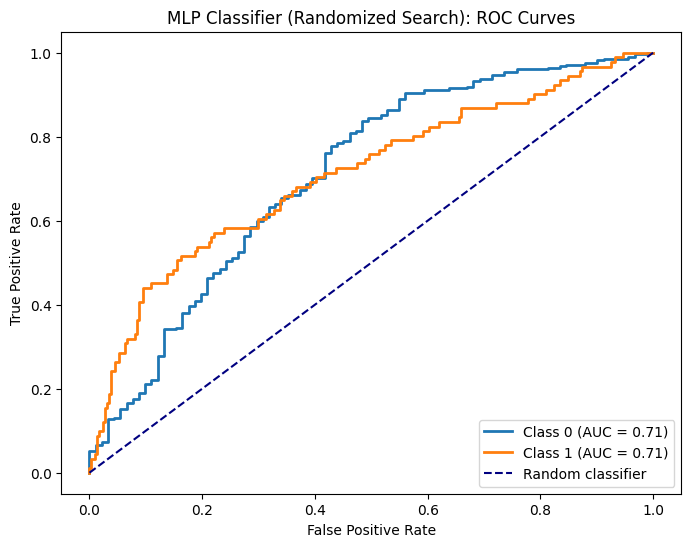

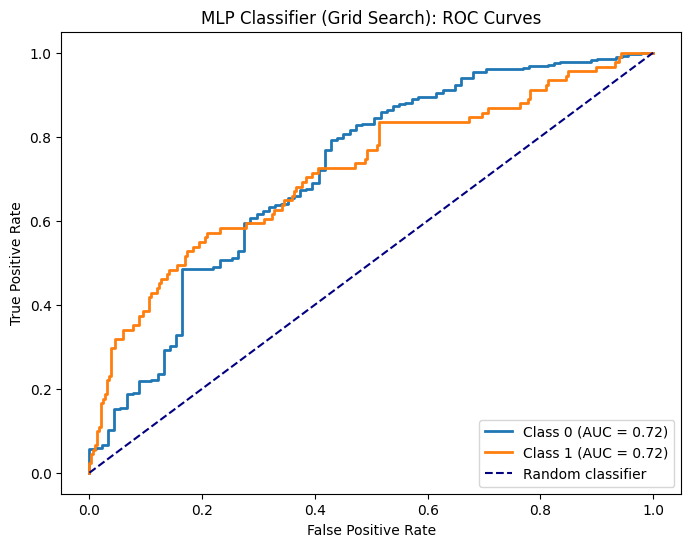

In [49]:
roc_auc(best_mlp_rand, "MLP Classifier (Randomized Search)", X_validation, y_validation)
roc_auc(best_mlp_grid, "MLP Classifier (Grid Search)", X_validation, y_validation)

- **AUC for Randomized Search Model**: 0.71  

- **AUC for Grid Search Model**: 0.72
Randomized Search Model achieve an AUC (Area Under the Curve) of 0.72, indicating that their ability to distinguish between clicked and non-clicked cases is slightly better than random guessing but still has room for improvement. The upward trajectory of both ROC curves demonstrates that the models capture meaningful patterns in the data.

#### Interpretation in Context

- **Strengths**:
  - Both MLP models perform better than the Decision Tree and Random Forest models in terms of recall and F1 score, indicating improved ability to identify users who click on ads.
  - High precision ensures that when the models predict a click, it is likely correct, which is critical for reducing wasted ad spend.
  - The slight improvements of the Randomized Search model over the Grid Search model suggest that broader exploration of hyperparameter space can yield marginally better results.

- **Weaknesses**:
  - While recall has improved, false negatives (72 for Grid Search and 71 for Randomized Search) are still notable, meaning some users who clicked on ads are missed.
  - The AUC of 0.70 shows the models are effective but not exceptional in distinguishing between clicked and non-clicked cases.

### Conclusion for MLP classifier

Both MLP models demonstrate robust performance, offering an improvement over simpler models like Decision Trees and Random Forests. The **Randomized Search MLP Classifier** slightly edges out the **Grid Search MLP Classifier** in recall, F1 score, and accuracy, making it the preferred choice for this task. However, further optimization and exploration of additional hyperparameters, as well as feature engineering, could help improve the models’ ability to minimize false negatives and further increase predictive performance.

# Chapter 6: overall conclusion

In [50]:
for model_name, metrics in scores_dict.items():
    print(f"\n{model_name} Metrics:")
    for metric, score in metrics.items():
        print(f"{metric}: {score}")


Decision Tree Metrics:
Precision: 0.7562
Recall: 0.6640
F1 Score: 0.6872
Accuracy: 0.6640

Random Forest Metrics:
Precision: 0.7575
Recall: 0.7173
F1 Score: 0.7311
Accuracy: 0.7173

MLP Classifier (Grid Search) Metrics:
Precision: 0.7646
Recall: 0.7867
F1 Score: 0.7636
Accuracy: 0.7867

MLP Classifier (Randomized Search) Metrics:
Precision: 0.7638
Recall: 0.7867
F1 Score: 0.7549
Accuracy: 0.7867


This study aimed to build and evaluate predictive models for user ad clicks using a dataset rich in user behavior metrics, such as cursor movement and session data. Three machine learning models were implemented: **Decision Tree Classifier**, **Random Forest Classifier**, and **Multi-Layer Perceptron (MLP) Classifier**. Each model offered unique insights and performance characteristics, with the goal of balancing interpretability, precision, recall, and overall accuracy.

## 6.1 Performance Overview

- **Decision Tree Classifier**:
  - Served as a baseline model, providing strong interpretability through its tree structure.
  - Achieved reasonable precision and a moderate recall, indicating it was better at avoiding false positives but missed some true positives (false negatives).
  - Accuracy of 66.40% reflects its overall performance but highlighted its limitations in handling class imbalance and complex patterns in the data.

- **Random Forest Classifier**:
  - Improved upon the Decision Tree by leveraging an ensemble of trees to reduce overfitting and enhance generalization.
  - Demonstrated higher recall and better accuracy, making it more effective at capturing true positives.
  - Precision remained slightly lower than the Decision Tree, indicating a trade-off between minimizing false positives and capturing true positives.
  - The AUC of 0.74 showed its ability to distinguish between clicked and non-clicked ads was better than random but not exceptional.

- **MLP Classifier**:
  - The MLP Classifier, tested using both Grid Search and Randomized Search, outperformed the Decision Tree and Random Forest in terms of recall, F1 score, and accuracy.
  - Grid Search MLP achieved the best overall metrics:
    - Precision: 76.46%
    - Recall: 78.67%
    - F1 Score: 76.36%
    - Accuracy: 78.67%
  - The MLP's ability to model nonlinear patterns and complex relationships in the dataset contributed to its superior performance. However, both versions of the MLP still struggled with false negatives, as highlighted by the confusion matrix.

## 6.2 Strengths and Limitations


- **Strengths**:
  - The Decision Tree provided valuable insights into feature importance and decision-making logic, making it highly interpretable.
  - Random Forest struck a balance between interpretability and improved predictive power, leveraging ensemble learning to boost performance.
  - The MLP Classifier excelled in identifying complex patterns in the data, achieving the highest recall and accuracy among the three models.

- **Limitations**:
  - All models exhibited some difficulty in minimizing false negatives (users who clicked but were misclassified), which is critical for maximizing ad engagement.
  - The AUC scores, while above random guessing, indicated room for improvement in distinguishing between classes.
  - The Random Forest and MLP models, while effective, were less interpretable compared to the Decision Tree, which may limit their utility in scenarios where model transparency is essential.

## 6.3 Contextual Implications

In the context of ad click prediction:
- **Decision Tree**: Best suited for situations where interpretability is paramount, and the ability to explain model predictions is critical. However, its predictive power is limited for complex datasets like this one.
- **Random Forest**: A reliable middle ground, offering better generalization than the Decision Tree while still being moderately interpretable. It is a good option for improving recall without significantly increasing complexity.
- **MLP Classifier**: The most effective model in terms of performance metrics, making it ideal for maximizing ad click predictions. However, it requires careful tuning and additional computational resources, and its lack of interpretability could pose challenges in highly regulated or explainability-focused environments.

## 6.4 Recommendations

- For a balance of performance and interpretability, **Random Forest** would be a practical choice for deployment. It provides solid predictive power while maintaining moderate transparency.
- To achieve the best predictive performance, the **MLP Classifier (Randomized Search)** should be adopted, especially in applications where capturing as many clicks as possible is critical (e.g., optimizing ad targeting). However, additional effort should be made to reduce false negatives and improve interpretability, potentially through techniques like SHAP values or feature visualization.
- Further improvements could be achieved by addressing class imbalance through techniques like SMOTE or cost-sensitive training and incorporating additional features or domain-specific knowledge to enrich the dataset.

## 6.5 Final Thoughts


This analysis highlights the strengths and trade-offs of different machine learning approaches for ad click prediction. While the Decision Tree provided valuable baseline insights, the Random Forest and MLP Classifiers demonstrated the ability to effectively handle the complexity and richness of the data. Future work should focus on improving recall and AUC scores while maintaining an acceptable balance between interpretability and performance, ensuring the chosen model aligns with both technical requirements and business goals.

# References

1. Google Auth Documentation. Available at: https://google-auth.readthedocs.io/en/latest/ [Accessed on: November 13, 2024].

2. Google Colab Drive Guide. Available at: https://colab.research.google.com/notebooks/io.ipynb [Accessed on: November 13, 2024].

3. Python Zipfile Documentation. Available at: https://docs.python.org/3/library/zipfile.html [Accessed on: November 13, 2024].

4. Python OS Module Documentation. Available at: https://docs.python.org/3/library/os.html [Accessed on: November 13, 2024].

5. Pandas Official Website. Available at: https://pandas.pydata.org/ [Accessed on: November 13, 2024].

6. Matplotlib Official Website. Available at: https://matplotlib.org/ [Accessed on: November 15, 2024].

7. Scikit-learn Official Website. Available at: https://scikit-learn.org/stable/ [Accessed on: November 20, 2024].

8. Scikit-learn Documentation: Confusion Matrix. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html [Accessed on: November 18, 2024].

9. Scikit-learn Documentation: RandomForestClassifier. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html [Accessed on: November 22, 2024].

10. Scikit-learn Documentation: DecisionTreeClassifier. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html [Accessed on: November 22, 2024].

11. Scikit-learn Documentation: MLPClassifier. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html [Accessed on: November 25, 2024].

12. Python Documentation: Handling Missing Data. Available at: https://pandas.pydata.org/docs/user_guide/missing_data.html [Accessed on: November 19, 2024].

13. Interaction with PhD students at Politecnico di Milano regarding machine learning methodologies and best practices, conducted via personal correspondence, November 2024.

14. Assistance from OpenAI’s ChatGPT for structuring machine learning workflows and clarifying technical aspects of predictive modeling.

15. Hands-on exploration of hyperparameter tuning using Scikit-learn GridSearchCV. Available at: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html [Accessed on: November 22, 2024].

16. Official Python Numpy Documentation. Available at: https://numpy.org/doc/stable/ [Accessed on: November 13, 2024].

17. Data Preprocessing Techniques for Machine Learning, Scikit-learn Documentation. Available at: https://scikit-learn.org/stable/modules/preprocessing.html [Accessed on: November 18, 2024].

18. Exploratory Data Analysis Best Practices. Kaggle Documentation. Available at: https://www.kaggle.com/learn/data-visualization [Accessed on: November 15, 2024].

19. Python Random Library Documentation. Available at: https://docs.python.org/3/library/random.html [Accessed on: November 25, 2024].

20. ROC Curve and AUC for Evaluating Classifier Performance, Scikit-learn User Guide. Available at: https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html [Accessed on: November 18, 2024].
---